In [1]:
!pip install icrawler



   ---------------------------------------- 2/2 [icrawler]



In [70]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Define hyperparameters
BATCH_SIZE = 16  # Using a smaller batch size since our dataset is relatively small
IMG_SIZE = (224, 224)  # 224x224 is the standard input size for most pre-trained models like MobileNetV2
DATA_DIR = 'Dataset'

print("Loading training data...")
# Load training dataset (80% of the images)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading validation data...")
# Load validation dataset (20% of the images)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract and verify class names
class_names = train_dataset.class_names
print(f"\nSuccessfully detected {len(class_names)} classes: {class_names}")


Loading training data...
Found 367 files belonging to 4 classes.
Using 294 files for training.

Loading validation data...
Found 367 files belonging to 4 classes.
Using 73 files for validation.

Successfully detected 4 classes: ['LeBron_James', 'Luka_Doncic', 'Shai_Gilgeous_Alexander', 'Unknown']


In [71]:
# Use Transfer Learning
import tensorflow as tf

print("Building the Transfer Learning model...")

# Data Augmentation: Make our 136 images look like a lot more by randomly flipping and rotating them
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
], name="Data_Augmentation")

#  Load the Pre-trained Base Model (MobileNetV2)
IMG_SHAPE = (224, 224, 3)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the Base Model 
base_model.trainable = False

# Create Custom Classification Head for our 3 NBA stars
global_average_layer = tf.keras.layers.GlobalAveragePooling2D(name="Global_Pooling")
# New output layer, softmax3 because we aim to classify 3 nba stars
prediction_layer = tf.keras.layers.Dense(4, activation='softmax', name="Final_Predictions")

# Build the Final Model Architecture
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)

# Preprocess inputs to the format of scales between -1 and 1
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pass through the frozen base model (training=False ensures BatchNormalization layers stay frozen)
x = base_model(x, training=False)

x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x) # Prevent overfitting
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs, name="NBA_Star_Classifier")

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model built successfully!")
model.summary()

Building the Transfer Learning model...
Model built successfully!


Model: "NBA_Star_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Data_Augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_8 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_8 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Global_Pooling                       │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Final_Predictions (Dense)            │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting the training process...
Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 399ms/step - accuracy: 0.8912 - loss: 0.3436 - val_accuracy: 0.8767 - val_loss: 0.5285
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 395ms/step - accuracy: 0.8844 - loss: 0.3477 - val_accuracy: 0.8630 - val_loss: 0.5250
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 0.9150 - loss: 0.2824 - val_accuracy: 0.8630 - val_loss: 0.5188
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - accuracy: 0.9014 - loss: 0.2955 - val_accuracy: 0.8630 - val_loss: 0.5151
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.9048 - loss: 0.2991 - val_accuracy: 0.8630 - val_loss: 0.5078
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - accuracy: 0.9286 - loss: 0.2599 - val_accuracy: 0.8493 - val_loss: 0.4997
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 0.9048 - loss: 0.2799 - val_accuracy: 0.8356 - val_loss: 0.4930
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.9252 

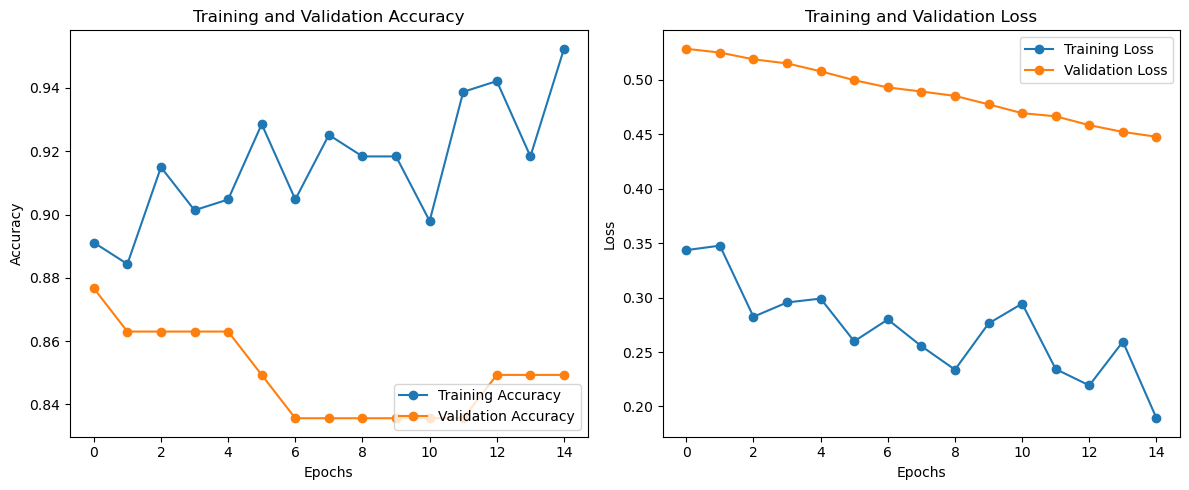

In [89]:

initial_epochs = 15

print("Starting the training process...")

# execute model train
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=initial_epochs
)

print("\nTraining completed! Plotting the learning curves...")

# Preparation for the curve
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

# Show the accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Draw out loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


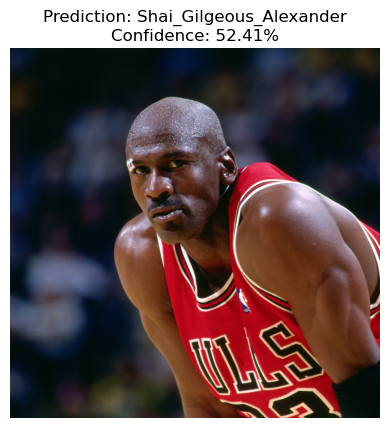

In [102]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

#  My test png path
test_image_path = os.path.join("test", "test10.jpg") 

#  load the test to 224x224 size
img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 


#  Predict and get the confidence level
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
confidence = 100 * np.max(predictions[0])

plt.imshow(image.load_img(test_image_path))
plt.axis('off')
plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.show()


In [83]:
import tensorflow as tf

print("Unfreezing the top layers of the base model...")

# Try to unfreeze the last 20 layers
base_model.trainable = True

# Show how many layers in the moel
print(f"Number of layers in the base model: {len(base_model.layers)}")
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile again with a small learning rate, prevent destroying the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

print("Ready for Fine-Tuning!")

Unfreezing the top layers of the base model...
Number of layers in the base model: 154


Model: "NBA_Star_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Data_Augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_8 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_8 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Global_Pooling                       │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Final_Predictions (Dense)            │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 1,211,204 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

Ready for Fine-Tuning!


In [109]:
%run train.py

Loading training data...
Found 367 files belonging to 4 classes.
Using 294 files for training.

Loading validation data...
Found 367 files belonging to 4 classes.
Using 73 files for validation.

Building the Transfer Learning model...

Starting the initial training process...
Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3980 - loss: 1.4055 - val_accuracy: 0.4932 - val_loss: 1.1007
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 692ms/step - accuracy: 0.6054 - loss: 0.9588 - val_accuracy: 0.6438 - val_loss: 0.8591
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.6565 - loss: 0.8594 - val_accuracy: 0.6849 - val_loss: 0.8400
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.7211 - loss: 0.7375 - val_accuracy: 0.7534 - val_loss: 0.7018
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 688ms/step - accuracy: 0.7857 - loss: 0.6137 - val_accuracy: 0.7534 - val_loss: 0.6797
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 697ms/step - accuracy: 0.8129 - loss: 0.

In [ ]:
%run crop_dataset.py